In [3]:
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import random
import pickle
import matplotlib.pyplot as plt

# -------------------------
# CONFIG
# -------------------------
PICKLE_FILE = "splined_trajectories_3.txt"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 8
LR = 1e-3
EPOCHS = 150

HIDDEN_SIZE = 64

TEACHER_FORCING_START = 1.0
TEACHER_FORCING_END = 0.1   # important: don't go to 0
SCHEDULE_EPOCHS = EPOCHS

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# -------------------------
# LOAD DATA
# -------------------------
with open(PICKLE_FILE, "rb") as f:
    output = pickle.load(f)

output = [np.array(t, dtype=np.float32) for t in output if len(t) > 0]

def moving_arm_and_target(traj): # returns the target position at the end of the traj
    left = traj[:, :2]; right = traj[:, 2:]
    if np.max(np.linalg.norm(left - left[0], axis=1)) > np.max(np.linalg.norm(right - right[0], axis=1)):
        return left[-1]
    else:
        return right[-1]

class TrajDataset(Dataset):
    def __init__(self, trajs):
        self.trajs = trajs

    def __len__(self):
        return len(self.trajs)

    def __getitem__(self, idx):
        traj = self.trajs[idx]
        target = moving_arm_and_target(traj)
        return traj, np.array(target, dtype=np.float32)

# split
idx = np.arange(len(output))
np.random.shuffle(idx)

val_split = int(0.2 * len(output))
train_trajs = [output[i] for i in idx[val_split:]]
val_trajs = [output[i] for i in idx[:val_split]]

train_loader = DataLoader(TrajDataset(train_trajs), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TrajDataset(val_trajs), batch_size=BATCH_SIZE, shuffle=False)

# -------------------------
# MODEL
# -------------------------
class LSTMModel(nn.Module):
    def __init__(self, input_dim=6, hidden_dim=HIDDEN_SIZE, output_dim=4):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, hidden):
        # x: (B, 1, input_dim)
        out, hidden = self.lstm(x, hidden)
        out = self.fc(out)  # (B, 1, 4)
        return out, hidden

    def init_hidden(self, batch_size=1):
        h0 = torch.zeros(1, batch_size, HIDDEN_SIZE).to(DEVICE)
        c0 = torch.zeros(1, batch_size, HIDDEN_SIZE).to(DEVICE)
        return (h0, c0)

model = LSTMModel().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
loss_fn = nn.MSELoss()

# -------------------------
# TEACHER FORCING SCHEDULE
# -------------------------
def teacher_forcing_prob(epoch):
    frac = min(1.0, epoch / float(SCHEDULE_EPOCHS))
    return TEACHER_FORCING_START + (TEACHER_FORCING_END - TEACHER_FORCING_START) * frac

# -------------------------
# TRAINING LOOP
# -------------------------
train_losses = []
val_losses = []

for epoch in range(1, EPOCHS+1):
    model.train()
    tf_p = teacher_forcing_prob(epoch)

    train_loss_epoch = 0.0

    for traj_batch, target_batch in train_loader:

        optimizer.zero_grad()
        batch_loss = 0.0

        for i in range(len(traj_batch)):

            traj = traj_batch[i].cpu().numpy()
            target = target_batch[i].cpu().numpy()

            T = traj.shape[0]
            target_vec = target.astype(np.float32)

            hidden = model.init_hidden(batch_size=1)

            prev = traj[0].copy()
            loss_traj = 0.0

            for t in range(1, T):

                inp = np.concatenate([target_vec, prev]).astype(np.float32)
                inp_t = torch.from_numpy(inp).float().to(DEVICE).view(1,1,-1)

                pred, hidden = model(inp_t, hidden)

                gt = torch.from_numpy(traj[t]).float().to(DEVICE).view(1,1,-1)
                loss_traj += loss_fn(pred, gt)

                # teacher forcing
                if random.random() < tf_p:
                    new_prev = traj[t].copy()
                else:
                    new_prev = pred.detach().cpu().numpy().reshape(4,)

                prev = new_prev

            loss_traj = loss_traj / (T-1)
            batch_loss += loss_traj

        batch_loss = batch_loss / len(traj_batch)
        batch_loss.backward()
        optimizer.step()

        train_loss_epoch += batch_loss.item()

    train_loss_epoch /= len(train_loader)

    # -------------------------
    # VALIDATION
    # -------------------------
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for traj_batch, target_batch in val_loader:

            for i in range(len(traj_batch)):

                traj = traj_batch[i].cpu().numpy()
                target = target_batch[i].cpu().numpy()

                T = traj.shape[0]
                target_vec = target.astype(np.float32)

                hidden = model.init_hidden(batch_size=1)
                prev = traj[0].copy()

                loss_traj = 0.0

                for t in range(1, T):

                    inp = np.concatenate([target_vec, prev]).astype(np.float32)
                    inp_t = torch.from_numpy(inp).float().to(DEVICE).view(1,1,-1)

                    pred, hidden = model(inp_t, hidden)

                    gt = torch.from_numpy(traj[t]).float().to(DEVICE).view(1,1,-1)
                    loss_traj += loss_fn(pred, gt)

                    # PURE AUTOREGRESSION
                    prev = pred.detach().cpu().numpy().reshape(4,)

                loss_traj = loss_traj / (T-1)
                val_loss += loss_traj.item()

    val_loss /= len(val_loader)

    train_losses.append(train_loss_epoch)
    val_losses.append(val_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch} | Train {train_loss_epoch:.4f} | Val {val_loss:.4f} | TF {tf_p:.3f}")

print("Training complete")

Epoch 1 | Train 0.0147 | Val 0.0549 | TF 0.994
Epoch 10 | Train 0.0004 | Val 0.0105 | TF 0.940
Epoch 20 | Train 0.0001 | Val 0.0053 | TF 0.880
Epoch 30 | Train 0.0001 | Val 0.0027 | TF 0.820
Epoch 40 | Train 0.0001 | Val 0.0012 | TF 0.760
Epoch 50 | Train 0.0000 | Val 0.0012 | TF 0.700
Epoch 60 | Train 0.0000 | Val 0.0006 | TF 0.640
Epoch 70 | Train 0.0000 | Val 0.0011 | TF 0.580
Epoch 80 | Train 0.0000 | Val 0.0003 | TF 0.520
Epoch 90 | Train 0.0000 | Val 0.0002 | TF 0.460
Epoch 100 | Train 0.0001 | Val 0.0005 | TF 0.400
Epoch 110 | Train 0.0000 | Val 0.0002 | TF 0.340
Epoch 120 | Train 0.0000 | Val 0.0001 | TF 0.280
Epoch 130 | Train 0.0000 | Val 0.0002 | TF 0.220
Epoch 140 | Train 0.0000 | Val 0.0002 | TF 0.160
Epoch 150 | Train 0.0000 | Val 0.0001 | TF 0.100
Training complete


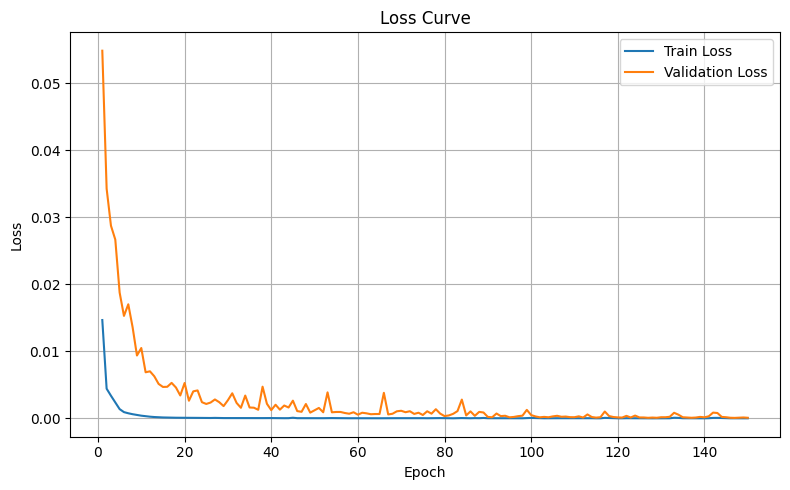

In [4]:
plt.figure(figsize=(8,5))

epochs = range(1, len(train_losses) + 1)

plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()